# MNIST Explanations: Structured Visualization + Robustness Scores

This notebook visualizes MNIST explanations from the three project explainers (`ig`, `dl`, `lrp`) and their robustness scores:
- **Case Align** (`S_plus`, `R_bounded`)
- **Captum Sensitivity** (`sensitivity_max`)

Each panel shows the **original image next to each explainer attribution** with per-sample scores.

In [79]:
from pathlib import Path
import sys
import subprocess

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

cwd = Path.cwd().resolve()
if (cwd / 'mnist_explain_predictions.py').exists():
    SRC_ROOT = cwd
elif (cwd / 'src' / 'mnist_explain_predictions.py').exists():
    SRC_ROOT = cwd / 'src'
elif (cwd.parent / 'mnist_explain_predictions.py').exists():
    SRC_ROOT = cwd.parent
else:
    raise RuntimeError('Could not locate src directory containing mnist_explain_predictions.py')

EXPLANATION_ARTIFACT  = SRC_ROOT / 'explanations' / 'mnist' / 'mnist_explanations.pt'
SANITY_ARTIFACT       = SRC_ROOT / 'explanations' / 'mnist' / 'mnist_sanity_explanations.pt'
PREDICTIONS_CSV       = SRC_ROOT / 'explanations' / 'mnist' / 'mnist_predictions.csv'
SCORES_CSV            = SRC_ROOT / 'explanations' / 'mnist' / 'mnist_explanation_scores.csv'
SUMMARY_CSV           = SRC_ROOT / 'explanations' / 'mnist' / 'mnist_method_summary.csv'
SANITY_SCORES_CSV     = SRC_ROOT / 'explanations' / 'mnist' / 'mnist_sanity_explanation_scores.csv'
SANITY_SUMMARY_CSV    = SRC_ROOT / 'explanations' / 'mnist' / 'mnist_sanity_method_summary.csv'
MODEL_PATH            = SRC_ROOT / 'models' / 'mnist' / 'mnist_best_model.pt'
DATA_DIR              = SRC_ROOT / 'data'

print(f'SRC_ROOT: {SRC_ROOT}')
print(f'Artifact exists:        {EXPLANATION_ARTIFACT.exists()}')
print(f'Sanity artifact exists: {SANITY_ARTIFACT.exists()}')
print(f'Scores exists:          {SCORES_CSV.exists()}')
print(f'Sanity scores exists:   {SANITY_SCORES_CSV.exists()}')

SRC_ROOT: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src
Artifact exists:        True
Sanity artifact exists: True
Scores exists:          True
Sanity scores exists:   True


In [ ]:
# Optional: run the full pipeline from notebook
RUN_PIPELINE = False
RUN_SANITY_CHECK = False
N_SAMPLES = 128
SANITY_LAYER_SCOPE = 'last'  # 'last' (default) or 'all'

if RUN_PIPELINE:
    explain_cmd = [
        sys.executable,
        str(SRC_ROOT / 'mnist_explain_predictions.py'),
        '--model-path', str(MODEL_PATH),
        '--data-dir', str(DATA_DIR),
        '--output-dir', str(SRC_ROOT / 'explanations' / 'mnist'),
        '--n-samples', str(N_SAMPLES),
        '--baseline-type', 'zero'
    ]
    eval_cmd = [
        sys.executable,
        str(SRC_ROOT / 'mnist_evaluate_explanations.py'),
        '--artifact-path', str(EXPLANATION_ARTIFACT),
        '--model-path', str(MODEL_PATH),
        '--data-dir', str(DATA_DIR),
        '--output-dir', str(SRC_ROOT / 'explanations' / 'mnist'),
        '--k', '5',
        '--sim-metric', 'gower',
        '--perturb-radius', '0.1',
        '--n-perturb-samples', '10',
        '--retrieval-batch-size', '256'
    ]

    print('Running explanation generation...')
    subprocess.run(explain_cmd, check=True)

    print('Running explanation evaluation...')
    subprocess.run(eval_cmd, check=True)

    if RUN_SANITY_CHECK:
        sanity_gen_cmd = [
            sys.executable,
            str(SRC_ROOT / 'mnist_sanity_check_explanations.py'),
            '--source-artifact', str(EXPLANATION_ARTIFACT),
            '--model-path', str(MODEL_PATH),
            '--output-dir', str(SRC_ROOT / 'explanations' / 'mnist'),
            '--layer-scope', SANITY_LAYER_SCOPE,
        ]
        print('Running sanity-check explanation generation...')
        subprocess.run(sanity_gen_cmd, check=True)

        sanity_eval_cmd = [
            sys.executable,
            str(SRC_ROOT / 'mnist_evaluate_explanations.py'),
            '--artifact-path', str(EXPLANATION_ARTIFACT),
            '--model-path', str(MODEL_PATH),
            '--data-dir', str(DATA_DIR),
            '--output-dir', str(SRC_ROOT / 'explanations' / 'mnist'),
            '--k', '5',
            '--sim-metric', 'gower',
            '--perturb-radius', '0.1',
            '--n-perturb-samples', '10',
            '--retrieval-batch-size', '256',
            '--sanity-artifact', str(SANITY_ARTIFACT),
            '--sanity-step-index', '-1',
        ]
        print('Running sanity-check explanation evaluation...')
        subprocess.run(sanity_eval_cmd, check=True)

    print('Pipeline complete ✅')
else:
    print('RUN_PIPELINE=False: skipping execution, loading existing artifacts only.')
    print('Set RUN_SANITY_CHECK=True when running pipeline to refresh sanity-check explanations/scores.')

RUN_PIPELINE=False: skipping execution, loading existing artifacts only.
Set RUN_SANITY_CHECK=True when running pipeline to refresh sanity-check explanations.


In [80]:
artifact = torch.load(EXPLANATION_ARTIFACT, map_location='cpu')
pred_df = pd.read_csv(PREDICTIONS_CSV)
scores_df = pd.read_csv(SCORES_CSV)
summary_df = pd.read_csv(SUMMARY_CSV)

images = artifact['images'].numpy()  # [N,1,28,28]
labels = artifact['labels'].numpy().astype(int)
pred_labels = artifact['pred_labels'].numpy().astype(int)
confidences = artifact['confidences'].numpy().astype(float)
methods = [m.lower() for m in artifact['methods']]
attributions = {m: artifact['attributions'][m].numpy() for m in methods}

sanity_artifact = None
sanity_steps = []
sanity_step_index = None

if SANITY_ARTIFACT.exists():
    sanity_artifact = torch.load(SANITY_ARTIFACT, map_location='cpu')
    sanity_steps = sanity_artifact.get('steps', [])
    if sanity_steps:
        sanity_step_index = len(sanity_steps) - 1  # default: latest incremental step
        print(
            f"Loaded sanity artifact with {len(sanity_steps)} step(s). "
            f"Using step: {sanity_steps[sanity_step_index].get('step_name', sanity_step_index)}"
        )
    else:
        print('Sanity artifact found but contains no steps.')
else:
    print(f'Sanity artifact not found: {SANITY_ARTIFACT}')

# Load sanity evaluation scores (computed by evaluator --sanity-artifact flag)
sanity_scores_df = None
sanity_summary_df_sanity = None
if SANITY_SCORES_CSV.exists():
    sanity_scores_df = pd.read_csv(SANITY_SCORES_CSV)
    sanity_scores_df['case_align_has_like_neighbour'] = sanity_scores_df['case_align_has_like_neighbour'].astype(bool)
    unsupported_sanity = ~sanity_scores_df['case_align_has_like_neighbour']
    sanity_scores_df.loc[unsupported_sanity, ['case_align_S_plus', 'case_align_R_bounded']] = np.nan
    print(f'Loaded sanity scores: {len(sanity_scores_df)} rows, step(s): {sanity_scores_df["sanity_step"].unique().tolist() if "sanity_step" in sanity_scores_df.columns else "N/A"}')
    if SANITY_SUMMARY_CSV.exists():
        sanity_summary_df_sanity = pd.read_csv(SANITY_SUMMARY_CSV)
else:
    print(f'Sanity scores not found ({SANITY_SCORES_CSV.name}). Run evaluator with --sanity-artifact to generate.')

if 'case_align_has_like_neighbour' in scores_df.columns:
    scores_df['case_align_has_like_neighbour'] = scores_df['case_align_has_like_neighbour'].astype(bool)
    unsupported_mask = ~scores_df['case_align_has_like_neighbour']
else:
    print('Legacy score file detected: inferring Case Align validity from subset class counts.')
    label_counts = pd.Series(labels).value_counts().astype(int)
    scores_df['case_align_class_count'] = scores_df['true_label'].map(label_counts).fillna(0).astype(int)
    scores_df['case_align_like_count'] = np.maximum(scores_df['case_align_class_count'] - 1, 0)
    scores_df['case_align_has_like_neighbour'] = scores_df['case_align_like_count'] > 0
    unsupported_mask = ~scores_df['case_align_has_like_neighbour']

scores_df.loc[unsupported_mask, ['case_align_S_plus', 'case_align_R_bounded']] = np.nan

if 'n_case_align_valid' not in summary_df.columns or summary_df.empty:
    summary_rows = []
    for method, group in scores_df.groupby('method'):
        valid = group.dropna(subset=['case_align_S_plus', 'captum_sensitivity'])
        if len(valid) >= 2:
            pearson_r = valid['case_align_S_plus'].corr(valid['captum_sensitivity'], method='pearson')
            spearman_r = valid['case_align_S_plus'].corr(valid['captum_sensitivity'], method='spearman')
        else:
            pearson_r = np.nan
            spearman_r = np.nan

        summary_rows.append(
            {
                'method': method,
                'n_samples': int(len(group)),
                'n_case_align_valid': int(len(valid)),
                'mean_case_align_S_plus': float(group['case_align_S_plus'].mean()),
                'mean_case_align_R_bounded': float(group['case_align_R_bounded'].mean()),
                'mean_captum_sensitivity': float(group['captum_sensitivity'].mean()),
                'std_captum_sensitivity': float(group['captum_sensitivity'].std()),
                'pearson_case_align_vs_sensitivity': float(pearson_r) if pd.notna(pearson_r) else np.nan,
                'pearson_p_value': np.nan,
                'spearman_case_align_vs_sensitivity': float(spearman_r) if pd.notna(spearman_r) else np.nan,
                'spearman_p_value': np.nan,
            }
        )

    summary_df = pd.DataFrame(summary_rows)

summary_df = summary_df.sort_values('method').reset_index(drop=True)

print(f'N images: {len(images)}, Methods: {methods}')
print(f'Case Align unavailable rows (baseline): {int(unsupported_mask.sum())}')
display(summary_df)

Loaded sanity artifact with 1 step(s). Using step: fc2
Loaded sanity scores: 72 rows, step(s): ['fc2']
N images: 24, Methods: ['ig', 'dl', 'lrp']
Case Align unavailable rows (baseline): 0


,method,n_samples,n_case_align_valid,mean_case_align_S_plus,mean_case_align_R_bounded,mean_captum_sensitivity,std_captum_sensitivity,pearson_case_align_vs_sensitivity,pearson_p_value,spearman_case_align_vs_sensitivity,spearman_p_value
0,dl,24,24,0.624679,0.624679,1.221421,0.260790,-0.087144,0.685554,-0.020000,0.926096
1,ig,24,24,0.925270,0.925270,0.815189,0.190495,-0.119976,0.576566,-0.151304,0.480346
2,lrp,24,24,0.625093,0.625093,0.389128,0.065643,0.011782,0.956425,-0.026087,0.903693


In [87]:
METHOD_LABEL = {'ig': 'Integrated Gradients', 'dl': 'DeepLift', 'lrp': 'LRP'}

def normalise_attr(attr_map: np.ndarray, percentile: float = 99.0) -> np.ndarray:
    arr = np.asarray(attr_map, dtype=float).squeeze()
    scale = np.percentile(np.abs(arr), percentile) + 1e-8
    arr = np.clip(arr / scale, -1.0, 1.0)
    return arr

def score_row(method: str, sample_position: int) -> pd.Series:
    row = scores_df[(scores_df['method'] == method) & (scores_df['sample_position'] == sample_position)]
    if row.empty:
        raise ValueError(f'No score row for method={method}, sample_position={sample_position}')
    return row.iloc[0]

def sanity_score_row(method: str, sample_position: int):
    """Return the sanity scores row for a given method/sample, or None if unavailable."""
    if sanity_scores_df is None:
        return None
    row = sanity_scores_df[
        (sanity_scores_df['method'] == method) &
        (sanity_scores_df['sample_position'] == sample_position)
    ]
    return row.iloc[0] if not row.empty else None

def _as_numpy(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().numpy()
    return np.asarray(value)

def _get_sanity_step():
    if sanity_artifact is None or sanity_step_index is None or not sanity_steps:
        return None
    if sanity_step_index < 0 or sanity_step_index >= len(sanity_steps):
        raise IndexError(f'sanity_step_index {sanity_step_index} out of range [0, {len(sanity_steps)-1}]')
    return sanity_steps[sanity_step_index]

def plot_sample_panel(sample_position: int, include_sanity: bool = True) -> None:
    if sample_position < 0 or sample_position >= len(images):
        raise IndexError(f'sample_position {sample_position} out of range [0, {len(images)-1}]')

    sanity_step = _get_sanity_step() if include_sanity else None
    has_sanity = sanity_step is not None

    n_cols = 1 + len(methods)
    n_rows = 2 if has_sanity else 1
    fig_h = 4.0 * n_rows
    fig_w = 4.2 * n_cols + 0.8
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))
    # Ensure axes is always 2-D
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    # Reserve right margin for colorbar before drawing anything
    fig.subplots_adjust(hspace=0.45, wspace=0.25, right=0.83, left=0.03, top=0.92, bottom=0.03)

    # ------------------------------------------------------------------
    # ROW 0: Original image + baseline explanations
    # ------------------------------------------------------------------
    axes[0, 0].imshow(images[sample_position, 0], cmap='gray')
    axes[0, 0].set_title(
        f'Original\nTrue={labels[sample_position]}, Pred={pred_labels[sample_position]}\nConf={confidences[sample_position]:.3f}'
    )
    axes[0, 0].axis('off')

    im = None
    for j, method in enumerate(methods, start=1):
        attr = normalise_attr(attributions[method][sample_position, 0])
        row = score_row(method, sample_position)

        s_plus = row['case_align_S_plus']
        r_bounded = row['case_align_R_bounded']
        s_plus_text = f'{s_plus:.3f}' if pd.notna(s_plus) else 'NA'
        r_bounded_text = f'{r_bounded:.3f}' if pd.notna(r_bounded) else 'NA'

        im = axes[0, j].imshow(attr, cmap='RdBu_r', vmin=-1, vmax=1)
        axes[0, j].set_title(
            f"{METHOD_LABEL.get(method, method.upper())}\n"
            f"S+={s_plus_text} | R={r_bounded_text}\n"
            f"Sens={row['captum_sensitivity']:.3f}"
        )
        axes[0, j].axis('off')

    # ------------------------------------------------------------------
    # ROW 1: Sanity-check explanations (if available)
    # ------------------------------------------------------------------
    if has_sanity:
        step_name = sanity_step.get('step_name', f'step_{sanity_step_index}')
        sanity_pred = sanity_step.get('pred_labels')
        sanity_conf = sanity_step.get('confidences')
        sanity_pred = _as_numpy(sanity_pred) if sanity_pred is not None else pred_labels
        sanity_conf = _as_numpy(sanity_conf) if sanity_conf is not None else confidences
        sanity_attributions = sanity_step.get('attributions', {})

        # Col 0: step label + sanity prediction/confidence
        axes[1, 0].axis('off')
        axes[1, 0].text(
            0.5, 0.5,
            f'Sanity\nStep: {step_name}\nPred={int(sanity_pred[sample_position])}\nConf={float(sanity_conf[sample_position]):.3f}',
            ha='center', va='center',
            transform=axes[1, 0].transAxes,
            fontsize=10, fontweight='bold'
        )

        for j, method in enumerate(methods, start=1):
            step_attr = sanity_attributions.get(method)
            if step_attr is None:
                axes[1, j].text(0.5, 0.5, 'Missing', ha='center', va='center', transform=axes[1, j].transAxes)
                axes[1, j].set_title(f"{METHOD_LABEL.get(method, method.upper())} (Sanity)")
                axes[1, j].axis('off')
                continue

            step_attr = _as_numpy(step_attr)
            attr = normalise_attr(step_attr[sample_position, 0])
            im = axes[1, j].imshow(attr, cmap='RdBu_r', vmin=-1, vmax=1)

            san = sanity_score_row(method, sample_position)
            if san is not None:
                s_text = f"{san['case_align_S_plus']:.3f}" if pd.notna(san['case_align_S_plus']) else 'NA'
                r_text = f"{san['case_align_R_bounded']:.3f}" if pd.notna(san['case_align_R_bounded']) else 'NA'
                axes[1, j].set_title(
                    f"{METHOD_LABEL.get(method, method.upper())} (Sanity)\n"
                    f"S+={s_text} | R={r_text}\n"
                    f"Sens={san['captum_sensitivity']:.3f}"
                )
            else:
                axes[1, j].set_title(
                    f"{METHOD_LABEL.get(method, method.upper())} (Sanity)\n"
                    f"Step={step_name}\n"
                    f"Pred={int(sanity_pred[sample_position])}, Conf={float(sanity_conf[sample_position]):.3f}"
                )
            axes[1, j].axis('off')

    if im is not None:
        # Explicit colorbar axes in the reserved right strip [left, bottom, width, height]
        cbar_ax = fig.add_axes([0.855, 0.15, 0.02, 0.70])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label('Attr.', rotation=270, labelpad=14)

    fig.suptitle(f'Sample {sample_position}', fontsize=14)
    plt.show()


Selected sample positions (low, median, high valid S+ based on IG): [3, 21, 1]


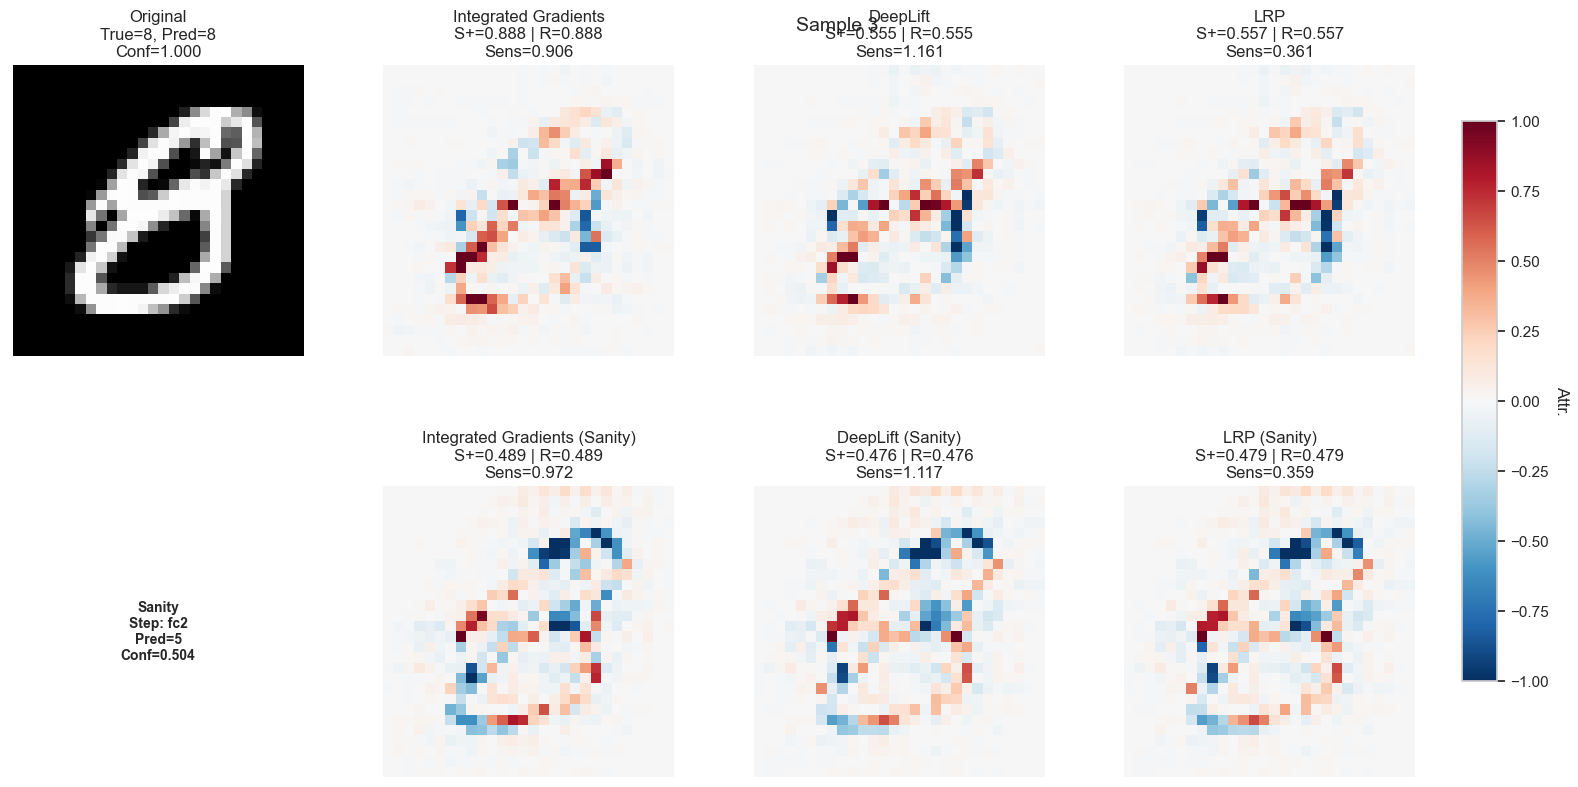

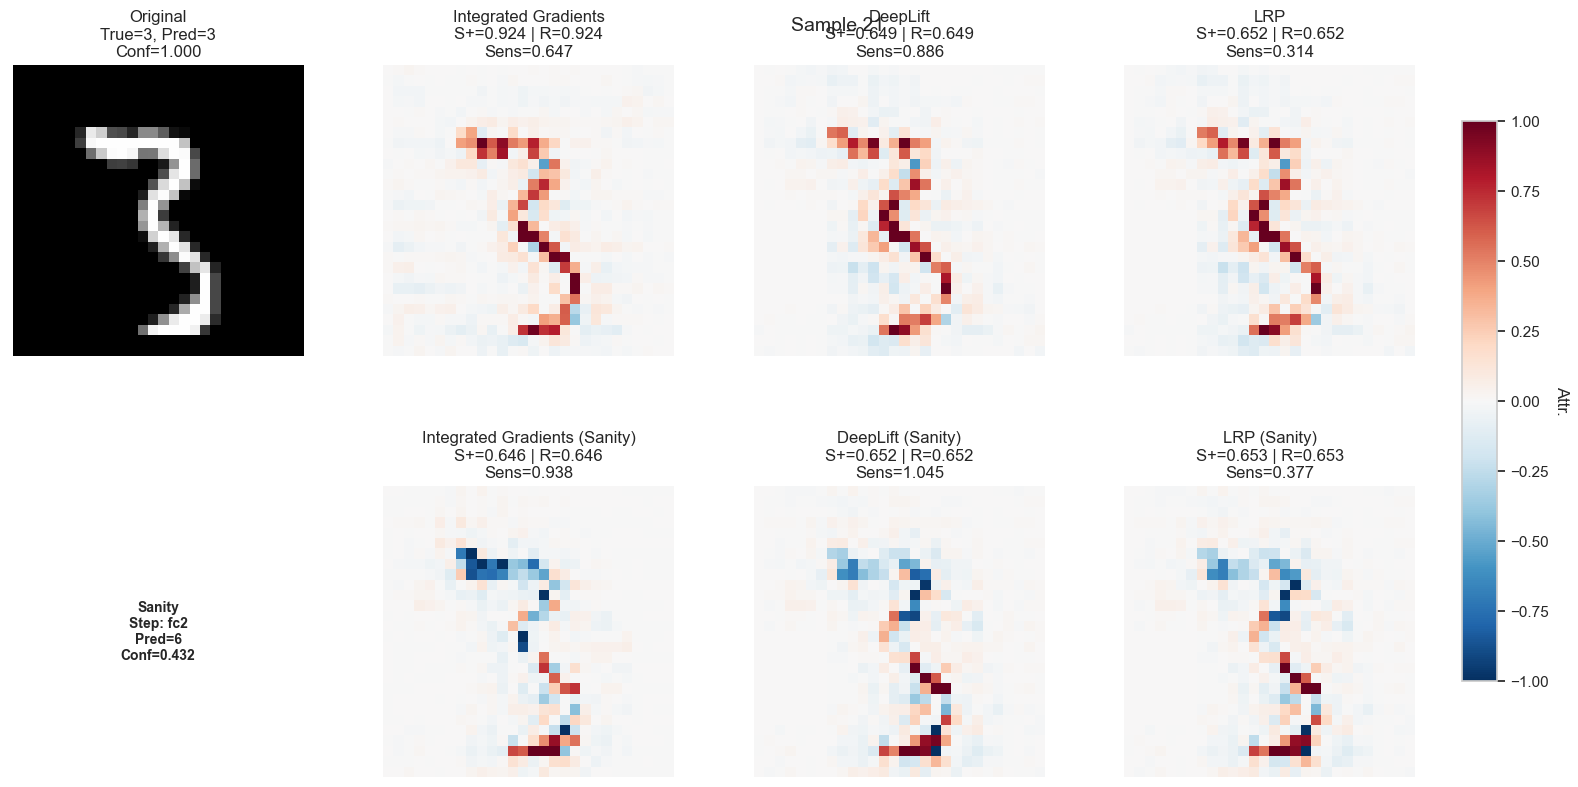

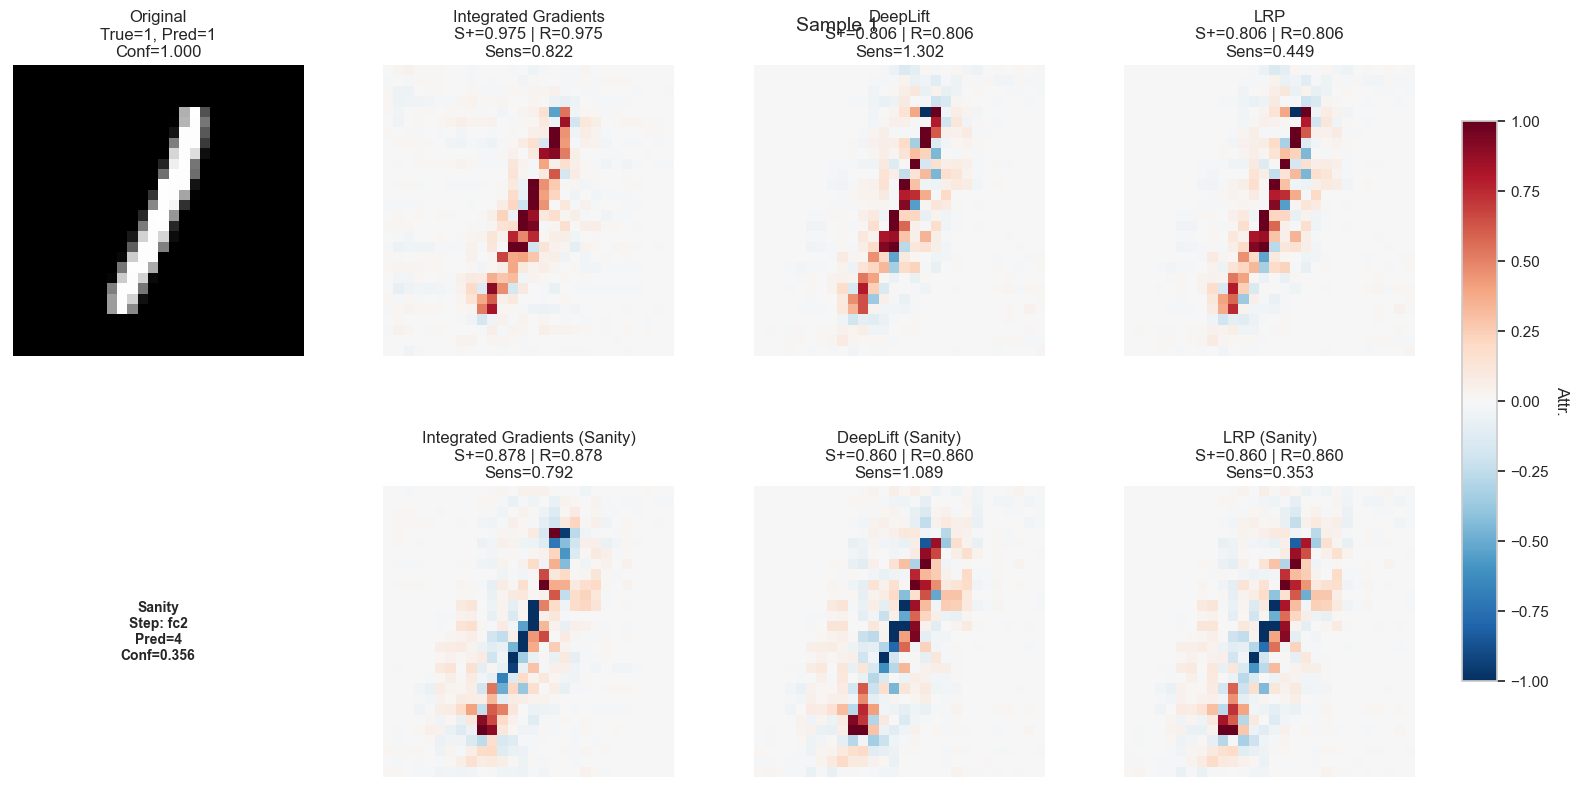

In [88]:
# Structured sample selection: low, median, high Case Align from IG (valid rows only)
ig_scores = scores_df[
    (scores_df['method'] == 'ig') & scores_df['case_align_S_plus'].notna()
].sort_values('case_align_S_plus').reset_index(drop=True)

if ig_scores.empty:
    raise ValueError('No valid IG rows for Case Align (all rows lack like-class neighbours).')

if len(ig_scores) >= 3:
    selected_positions = [
        int(ig_scores.iloc[0]['sample_position']),
        int(ig_scores.iloc[len(ig_scores) // 2]['sample_position']),
        int(ig_scores.iloc[len(ig_scores) - 1]['sample_position']),
    ]
else:
    selected_positions = ig_scores['sample_position'].astype(int).tolist()

print('Selected sample positions (low, median, high valid S+ based on IG):', selected_positions)

for sample_position in selected_positions:
    plot_sample_panel(sample_position)

/var/folders/wc/1h7jfddj0vg_39q37rx0sg7r0000gn/T/ipykernel_12802/1840911069.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='method', y='mean_case_align_S_plus', ax=axes[0], palette='Blues_d')
/var/folders/wc/1h7jfddj0vg_39q37rx0sg7r0000gn/T/ipykernel_12802/1840911069.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='method', y='mean_case_align_R_bounded', ax=axes[1], palette='Greens_d')
/var/folders/wc/1h7jfddj0vg_39q37rx0sg7r0000gn/T/ipykernel_12802/1840911069.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effec

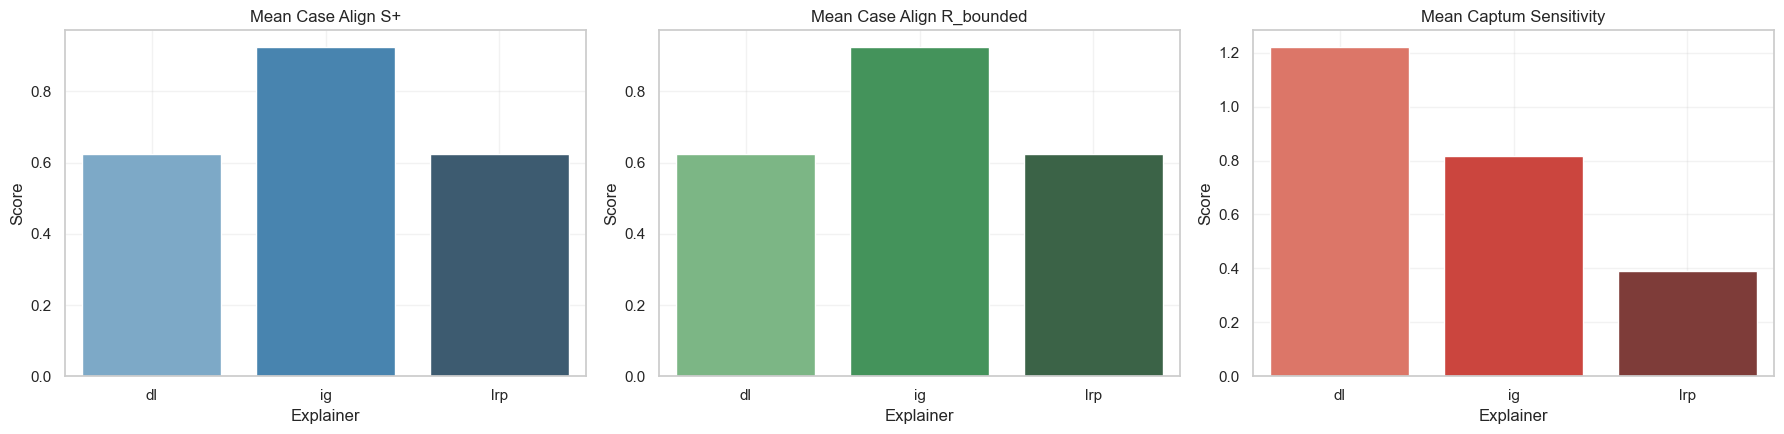

,method,n_samples,n_case_align_valid,mean_case_align_S_plus,mean_case_align_R_bounded,mean_captum_sensitivity,std_captum_sensitivity,pearson_case_align_vs_sensitivity,pearson_p_value,spearman_case_align_vs_sensitivity,spearman_p_value
0,dl,24,24,0.624679,0.624679,1.221421,0.260790,-0.087144,0.685554,-0.020000,0.926096
1,ig,24,24,0.925270,0.925270,0.815189,0.190495,-0.119976,0.576566,-0.151304,0.480346
2,lrp,24,24,0.625093,0.625093,0.389128,0.065643,0.011782,0.956425,-0.026087,0.903693


In [74]:
# Method-level score comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

sns.barplot(data=summary_df, x='method', y='mean_case_align_S_plus', ax=axes[0], palette='Blues_d')
axes[0].set_title('Mean Case Align S+')
axes[0].set_xlabel('Explainer')
axes[0].set_ylabel('Score')

sns.barplot(data=summary_df, x='method', y='mean_case_align_R_bounded', ax=axes[1], palette='Greens_d')
axes[1].set_title('Mean Case Align R_bounded')
axes[1].set_xlabel('Explainer')
axes[1].set_ylabel('Score')

sns.barplot(data=summary_df, x='method', y='mean_captum_sensitivity', ax=axes[2], palette='Reds_d')
axes[2].set_title('Mean Captum Sensitivity')
axes[2].set_xlabel('Explainer')
axes[2].set_ylabel('Score')

for ax in axes:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

display(summary_df)

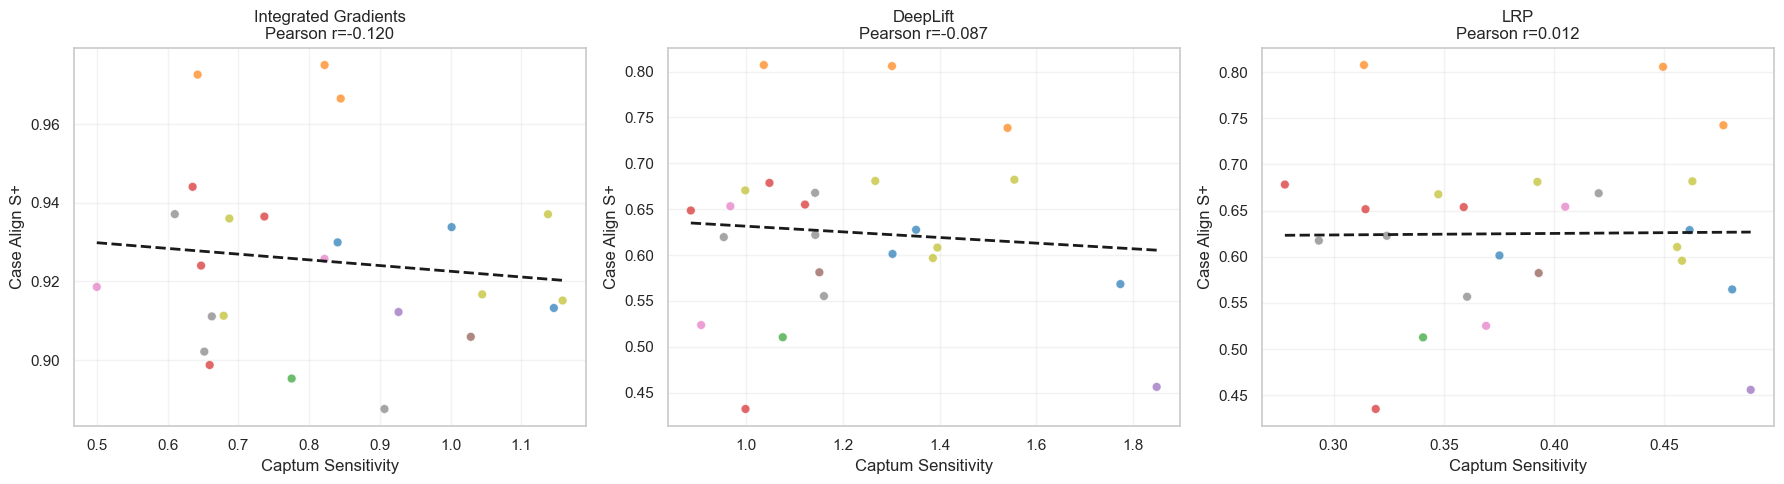

In [75]:
# Correlation view: Case Align vs Captum Sensitivity by method
fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 5), squeeze=False)

for i, method in enumerate(methods):
    ax = axes[0, i]
    sub = scores_df[
        (scores_df['method'] == method) & scores_df['case_align_S_plus'].notna()
    ]

    if len(sub) >= 2:
        sns.scatterplot(
            data=sub,
            x='captum_sensitivity',
            y='case_align_S_plus',
            hue='true_label',
            palette='tab10',
            alpha=0.7,
            s=40,
            legend=False,
            ax=ax,
        )

        z = np.polyfit(sub['captum_sensitivity'], sub['case_align_S_plus'], 1)
        p = np.poly1d(z)
        x_sorted = np.sort(sub['captum_sensitivity'].values)
        ax.plot(x_sorted, p(x_sorted), 'k--', linewidth=2)

        corr = sub['case_align_S_plus'].corr(sub['captum_sensitivity'], method='pearson')
    else:
        corr = np.nan
        ax.text(0.5, 0.5, 'Insufficient valid points', ha='center', va='center', transform=ax.transAxes)

    corr_text = f'{corr:.3f}' if pd.notna(corr) else 'NA'
    ax.set_title(f"{METHOD_LABEL.get(method, method.upper())}\nPearson r={corr_text}")
    ax.set_xlabel('Captum Sensitivity')
    ax.set_ylabel('Case Align S+')
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## How to use

1. Run `mnist_explain_predictions.py` to generate explanation artifact(s).
2. Run `mnist_evaluate_explanations.py` to compute Case Align and Captum sensitivity scores.
3. (Optional sanity check) Run `mnist_sanity_check_explanations.py` to generate randomized-layer sanity explanations (`mnist_sanity_explanations.pt`).
4. Re-run this notebook to inspect baseline and sanity-check maps side by side, plus score summaries.